<a href="https://colab.research.google.com/github/muhammadnouman911/Autoencoder/blob/main/Variational_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install torch torchvision matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 112.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
# ----------------------------
# Config
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 128
batch_size = 128
epochs = 30
lr = 1e-3

In [ ]:
# ----------------------------
# Data Loaders
# ----------------------------
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)


100%|██████████| 170M/170M [00:19<00:00, 8.96MB/s]


In [ ]:
# ----------------------------
# VAE Model
# ----------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  # (32, 16, 16)
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), # (64, 8, 8)
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),# (128, 4, 4)
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

        # Decoder
        self.fc_decode = nn.Linear(latent_dim, 128 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), # (64, 8, 8)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # (32, 16, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),   # (3, 32, 32)
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 128, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


In [ ]:
# ----------------------------
# Loss Function
# ----------------------------
def loss_function(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl

In [ ]:
# ----------------------------
# Training
# ----------------------------
model = VAE(latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        x, _ = batch
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        loss = loss_function(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(train_loader.dataset):.4f}")


Epoch [1/30], Loss: 115.5967
Epoch [2/30], Loss: 83.5007
Epoch [3/30], Loss: 79.5794
Epoch [4/30], Loss: 78.3350
Epoch [5/30], Loss: 77.5536
Epoch [6/30], Loss: 76.9895
Epoch [7/30], Loss: 76.5624
Epoch [8/30], Loss: 76.1354
Epoch [9/30], Loss: 75.8795
Epoch [10/30], Loss: 75.5841
Epoch [11/30], Loss: 75.3991
Epoch [12/30], Loss: 75.2839
Epoch [13/30], Loss: 75.1090
Epoch [14/30], Loss: 75.0284
Epoch [15/30], Loss: 74.9052
Epoch [16/30], Loss: 74.7804
Epoch [17/30], Loss: 74.6199
Epoch [18/30], Loss: 74.5558
Epoch [19/30], Loss: 74.5091
Epoch [20/30], Loss: 74.4311
Epoch [21/30], Loss: 74.4267
Epoch [22/30], Loss: 74.3304
Epoch [23/30], Loss: 74.2518
Epoch [24/30], Loss: 74.1910
Epoch [25/30], Loss: 74.1178
Epoch [26/30], Loss: 74.1093
Epoch [27/30], Loss: 74.0687
Epoch [28/30], Loss: 74.0102
Epoch [29/30], Loss: 73.9333
Epoch [30/30], Loss: 73.9315


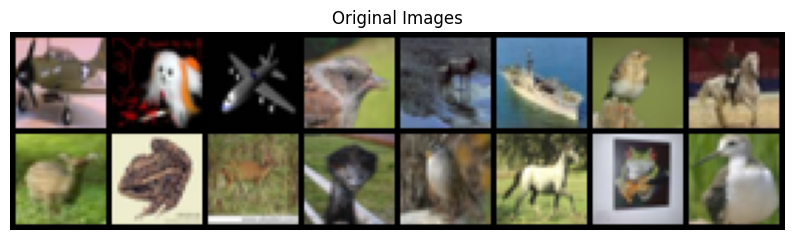

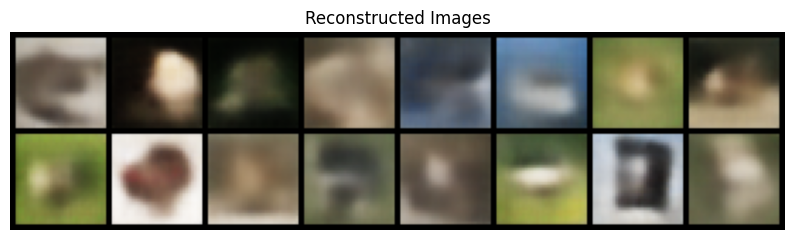

In [ ]:
# ----------------------------
# Show Reconstructions
# ----------------------------
def show_images(imgs, title):
    imgs = imgs.cpu()
    grid = make_grid(imgs, nrow=8)
    plt.figure(figsize=(10, 5))
    plt.title(title)
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.show()

model.eval()
with torch.no_grad():
    sample = next(iter(train_loader))[0].to(device)[:16]
    recon, _, _ = model(sample)
    show_images(sample, "Original Images")
    show_images(recon, "Reconstructed Images")


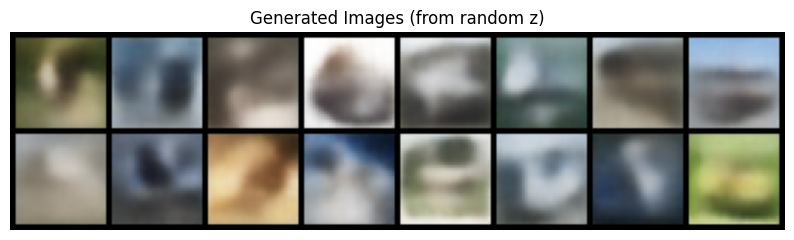

In [ ]:
# ----------------------------
# Generate New Images
# ----------------------------
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    generated = model.decode(z)
    show_images(generated, "Generated Images (from random z)")